<a href="https://colab.research.google.com/github/yandri918/belajar_machine_learning_buku_ONNO-W-Purba/blob/1April2026/Load_data_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("segmentasi_pelanggan.csv")

In [3]:
print("=== DATA AWAL ===")
print(df)
print("\n=== DESCRIBE ===")
print(df.describe())

=== DATA AWAL ===
   pelanggan  pendapatan_tahunan  skor_belanja
0         P1                  15            39
1         P2                  16            81
2         P3                  17             6
3         P4                  18            77
4         P5                  35            40
5         P6                  36            76
6         P7                  37             6
7         P8                  38            72
8         P9                  60            55
9        P10                  62            52
10       P11                  64            59
11       P12                  66            54
12       P13                  90            20
13       P14                  92            18
14       P15                  94            22
15       P16                  96            19

=== DESCRIBE ===
       pendapatan_tahunan  skor_belanja
count           16.000000     16.000000
mean            52.250000     43.500000
std             29.731016     25.899807
min  

In [4]:
X = df[["pendapatan_tahunan", "skor_belanja"]]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# 4. K-Means
model = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X_scaled)

In [16]:
print("=== HASIL CLUSTERING ===")
print(df)

=== HASIL CLUSTERING ===
   pelanggan  pendapatan_tahunan  skor_belanja  cluster
0         P1                  15            39        1
1         P2                  16            81        0
2         P3                  17             6        1
3         P4                  18            77        0
4         P5                  35            40        1
5         P6                  36            76        0
6         P7                  37             6        1
7         P8                  38            72        0
8         P9                  60            55        0
9        P10                  62            52        0
10       P11                  64            59        0
11       P12                  66            54        0
12       P13                  90            20        2
13       P14                  92            18        2
14       P15                  94            22        2
15       P16                  96            19        2


In [17]:
print("\nCentroid (skala standar):")
print(model.cluster_centers_)


Centroid (skala standar):
[[-0.25185038  0.88725376]
 [-0.91187207 -0.8274389 ]
 [ 1.41557283 -0.94706862]]


**elbow_method**

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [19]:
df = pd.read_csv("segmentasi_pelanggan.csv")

In [21]:
X = df[["pendapatan_tahunan", "skor_belanja"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
inertia_values = []

In [23]:
for k in range(1, 8):
  model = KMeans(n_clusters=k, random_state=42, n_init=10)
  model.fit(X_scaled)
  inertia_values.append(model.inertia_)

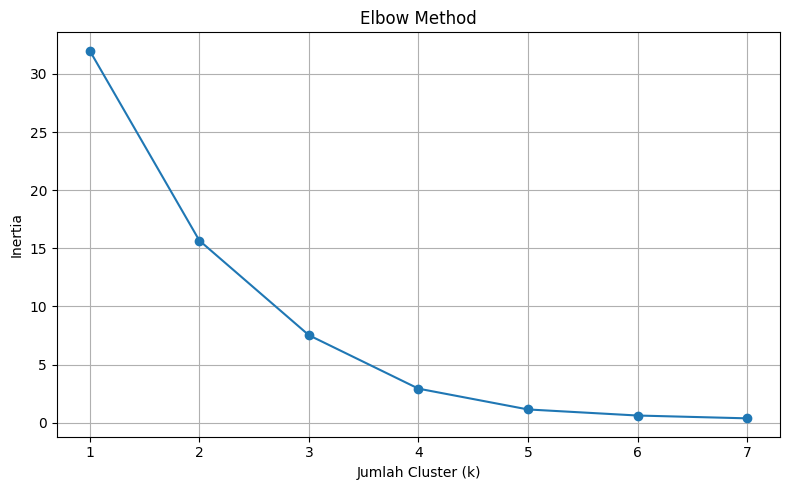

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), inertia_values, marker="o")
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

**silhouette_score**

In [26]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [27]:
df = pd.read_csv("segmentasi_pelanggan.csv")

In [28]:
X = df[["pendapatan_tahunan", "skor_belanja"]]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.29398989 -0.17944458]
 [-1.25925191  1.49537151]
 [-1.22451392 -1.49537151]
 [-1.18977594  1.33586522]
 [-0.59923022 -0.13956801]
 [-0.56449223  1.29598864]
 [-0.52975425 -1.49537151]
 [-0.49501627  1.13648235]
 [ 0.26921937  0.4585806 ]
 [ 0.33869534  0.33895088]
 [ 0.40817131  0.61808689]
 [ 0.47764727  0.41870402]
 [ 1.31135888 -0.93709948]
 [ 1.38083485 -1.01685263]
 [ 1.45031082 -0.85734633]
 [ 1.51978678 -0.97697605]]


In [30]:
for k in range(2, 7):
  model = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = model.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  print(f"k={k}, silhouette_score={score:.4f}")

k=2, silhouette_score=0.4717
k=3, silhouette_score=0.5591
k=4, silhouette_score=0.6735
k=5, silhouette_score=0.7133
k=6, silhouette_score=0.7448
